# Prodigy InfoTech - Task 03: Text Generation with Markov Chains

In [1]:
import re
import math
import random
import json
import collections
from typing import Dict, List, Tuple, Union, Optional

import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Libraries successfully imported!")

Libraries successfully imported!


In [2]:
class BaseMarkovChain:

    def __init__(self, order: int = 2):
        if order < 1:
            raise ValueError("Markov Chain order must be >= 1.")
        self.order: int = order
        self.transitions: Dict[Tuple[str, ...], collections.Counter] = collections.defaultdict(collections.Counter)
        self.initial_prefixes: List[Tuple[str, ...]] = []
        self.vocabulary: set[str] = set()

    def get_probabilities(self, prefix: Tuple[str, ...], temperature: float = 1.0) -> Dict[str, float]:
        counts = self.transitions.get(prefix)
        if not counts:
            return {}

        total = sum(counts.values())
        if temperature <= 0:
            max_token = counts.most_common(1)[0][0]
            return {max_token: 1.0}

        if temperature == 1.0:
            return {token: count / total for token, count in counts.items()}

        tokens = list(counts.keys())
        scaled_logits = [math.pow(counts[t] / total, 1.0 / temperature) for t in tokens]
        norm = sum(scaled_logits)
        return {token: prob / norm for token, prob in zip(tokens, scaled_logits)}

    def sample_next(self, prefix: Tuple[str, ...], temperature: float = 1.0, top_k: Optional[int] = None) -> Optional[str]:
        probs_dict = self.get_probabilities(prefix, temperature=temperature)
        if not probs_dict:
            return None

        items = sorted(probs_dict.items(), key=lambda x: x[1], reverse=True)
        if top_k is not None and top_k > 0:
            items = items[:top_k]
            sum_prob = sum(p for _, p in items)
            items = [(t, p / sum_prob) for t, p in items]

        tokens = [t for t, _ in items]
        probabilities = [p for _, p in items]
        return random.choices(tokens, weights=probabilities, k=1)[0]

    def save_model(self, filepath: str) -> None:
        data = {
            "order": self.order,
            "vocabulary": list(self.vocabulary),
            "initial_prefixes": [list(p) for p in self.initial_prefixes],
            "transitions": {"___".join(k): dict(v) for k, v in self.transitions.items()}
        }
        with open(filepath, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=2, ensure_ascii=False)

    def load_model(self, filepath: str) -> None:
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
        self.order = data["order"]
        self.vocabulary = set(data.get("vocabulary", []))
        self.initial_prefixes = [tuple(p) for p in data.get("initial_prefixes", [])]
        self.transitions = collections.defaultdict(collections.Counter)
        for k_str, counter_dict in data.get("transitions", {}).items():
            k_tuple = tuple(k_str.split("___"))
            self.transitions[k_tuple] = collections.Counter(counter_dict)


In [3]:
class WordMarkovChain(BaseMarkovChain):

    @staticmethod
    def tokenize(text: str) -> List[str]:
        return re.findall(r"\b\w+(?:'\w+)?\b|[.,!?;:\"]", text)

    def train(self, corpus: Union[str, List[str]]) -> None:
        documents = [corpus] if isinstance(corpus, str) else corpus

        for doc in documents:
            tokens = self.tokenize(doc)
            if len(tokens) <= self.order:
                continue
            self.vocabulary.update(tokens)

            for i in range(len(tokens) - self.order):
                prefix = tuple(tokens[i : i + self.order])
                next_word = tokens[i + self.order]
                self.transitions[prefix][next_word] += 1

                if prefix[0][0].isupper() or i == 0:
                    self.initial_prefixes.append(prefix)

    def generate(
        self,
        max_words: int = 50,
        prompt: Optional[str] = None,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        stop_at_sentence_end: bool = False,
        seed: Optional[int] = None
    ) -> str:
        if seed is not None:
            random.seed(seed)
        if not self.transitions:
            raise RuntimeError("Model is not trained. Call train() first.")

        if prompt:
            prompt_tokens = self.tokenize(prompt)
            if len(prompt_tokens) >= self.order:
                prefix = tuple(prompt_tokens[-self.order:])
                output_tokens = list(prompt_tokens)
            else:
                matched = [p for p in self.transitions if " ".join(p).lower().startswith(prompt.lower())]
                prefix = random.choice(matched) if matched else random.choice(self.initial_prefixes or list(self.transitions.keys()))
                output_tokens = list(prefix)
        else:
            prefix = random.choice(self.initial_prefixes or list(self.transitions.keys()))
            output_tokens = list(prefix)

        for _ in range(max_words - len(output_tokens)):
            next_word = self.sample_next(prefix, temperature=temperature, top_k=top_k)
            if next_word is None:
                prefix = random.choice(self.initial_prefixes or list(self.transitions.keys()))
                continue
            output_tokens.append(next_word)
            prefix = tuple(output_tokens[-self.order:])
            if stop_at_sentence_end and len(output_tokens) >= 15 and next_word in {".", "!", "?"}:
                break

        return self._detokenize(output_tokens)

    @staticmethod
    def _detokenize(tokens: List[str]) -> str:
        if not tokens:
            return ""
        result = []
        no_space_before = {".", ",", "!", "?", ";", ":", ")", "]", "}", "'"}
        no_space_after = {"(", "[", "{", "@", "$"}
        skip_space = False
        for i, token in enumerate(tokens):
            if i == 0 or token in no_space_before or skip_space:
                result.append(token)
            else:
                result.append(" " + token)
            skip_space = token in no_space_after
        text = "".join(result)
        return re.sub(r'(^|[.!?]\s+)([a-z])', lambda m: m.group(1) + m.group(2).upper(), text)

In [4]:
class CharacterMarkovChain(BaseMarkovChain):

    def __init__(self, order: int = 5):
        super().__init__(order=order)

    def train(self, corpus: Union[str, List[str]]) -> None:
        documents = [corpus] if isinstance(corpus, str) else corpus
        for doc in documents:
            if len(doc) <= self.order:
                continue
            self.vocabulary.update(set(doc))
            for i in range(len(doc) - self.order):
                prefix = tuple(doc[i : i + self.order])
                next_char = doc[i + self.order]
                self.transitions[prefix][next_char] += 1
                if i == 0 or (prefix[0].isupper() and (i == 0 or doc[i - 1] in {" ", "\n", "."})):
                    self.initial_prefixes.append(prefix)

    def generate(
        self,
        max_chars: int = 300,
        prompt: Optional[str] = None,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        seed: Optional[int] = None
    ) -> str:
        if seed is not None:
            random.seed(seed)
        if not self.transitions:
            raise RuntimeError("Model is not trained. Call train() first.")

        if prompt:
            if len(prompt) >= self.order:
                prefix = tuple(prompt[-self.order:])
                output_chars = list(prompt)
            else:
                matched = [p for p in self.transitions if "".join(p).startswith(prompt)]
                prefix = random.choice(matched) if matched else random.choice(self.initial_prefixes or list(self.transitions.keys()))
                output_chars = list(prefix)
        else:
            prefix = random.choice(self.initial_prefixes or list(self.transitions.keys()))
            output_chars = list(prefix)

        for _ in range(max_chars - len(output_chars)):
            next_char = self.sample_next(prefix, temperature=temperature, top_k=top_k)
            if next_char is None:
                prefix = random.choice(self.initial_prefixes or list(self.transitions.keys()))
                continue
            output_chars.append(next_char)
            prefix = tuple(output_chars[-self.order:])

        return "".join(output_chars)

In [5]:
class MarkovModelEvaluator:

    @staticmethod
    def calculate_perplexity(model: BaseMarkovChain, test_text: str, is_character: bool = False, laplace_alpha: float = 0.01) -> float:
        tokens = list(test_text) if is_character else WordMarkovChain.tokenize(test_text)
        if len(tokens) <= model.order:
            return float("nan")

        vocab_size = max(len(model.vocabulary), 1)
        total_log_likelihood = 0.0
        n_eval = 0

        for i in range(len(tokens) - model.order):
            prefix = tuple(tokens[i : i + model.order])
            target = tokens[i + model.order]
            counts = model.transitions.get(prefix, collections.Counter())
            prefix_total = sum(counts.values())

            target_count = counts.get(target, 0)
            prob = (target_count + laplace_alpha) / (prefix_total + laplace_alpha * vocab_size)
            total_log_likelihood += math.log(prob)
            n_eval += 1

        if n_eval == 0:
            return float("inf")
        cross_entropy = -total_log_likelihood / n_eval
        return math.exp(cross_entropy)

In [6]:
CORPUS_DATA = {
    "AI_DataScience": """
    Artificial intelligence and machine learning algorithms have revolutionized natural language processing.
    A Markov chain is a stochastic model describing a sequence of possible events in which the probability of each event
    depends only on the state attained in the previous event. In statistical modeling, n-gram Markov models predict
    the probability distribution of the next word given a historical window of context. Machine learning pipelines
    involve data collection, preprocessing, exploratory analysis, model training, hyperparameter tuning, and deployment.
    Large language models build upon high-dimensional embeddings and self-attention mechanisms, while discrete Markov
    models provide transparent, interpretable, and computationally lightweight baselines for probabilistic text generation.
    """,
    "Classic_Literature": """
    It was the best of times, it was the worst of times, it was the age of wisdom, it was the age of foolishness.
    It was the epoch of belief, it was the epoch of incredulity, it was the season of light, it was the season of darkness.
    We had everything before us, we had nothing before us, we were all going direct to Heaven, we were all going direct the other way.
    To be or not to be, that is the question: whether 'tis nobler in the mind to suffer the slings and arrows of outrageous fortune,
    or to take arms against a sea of troubles and by opposing end them. All the world's a stage, and all the men and women merely players.
    They have their exits and their entrances, and one man in his time plays many parts, his acts being seven ages.
    """
}

combined_corpus = CORPUS_DATA["AI_DataScience"] + "\n" + CORPUS_DATA["Classic_Literature"]

word_markov = WordMarkovChain(order=2)
word_markov.train(combined_corpus)

char_markov = CharacterMarkovChain(order=4)
char_markov.train(combined_corpus)

print(f"Word Model: {len(word_markov.vocabulary)} unique words, {len(word_markov.transitions)} unique state prefixes.")
print(f"Char Model: {len(char_markov.vocabulary)} unique characters, {len(char_markov.transitions)} unique state prefixes.")

Word Model: 161 unique words, 242 unique state prefixes.
Char Model: 39 unique characters, 1111 unique state prefixes.


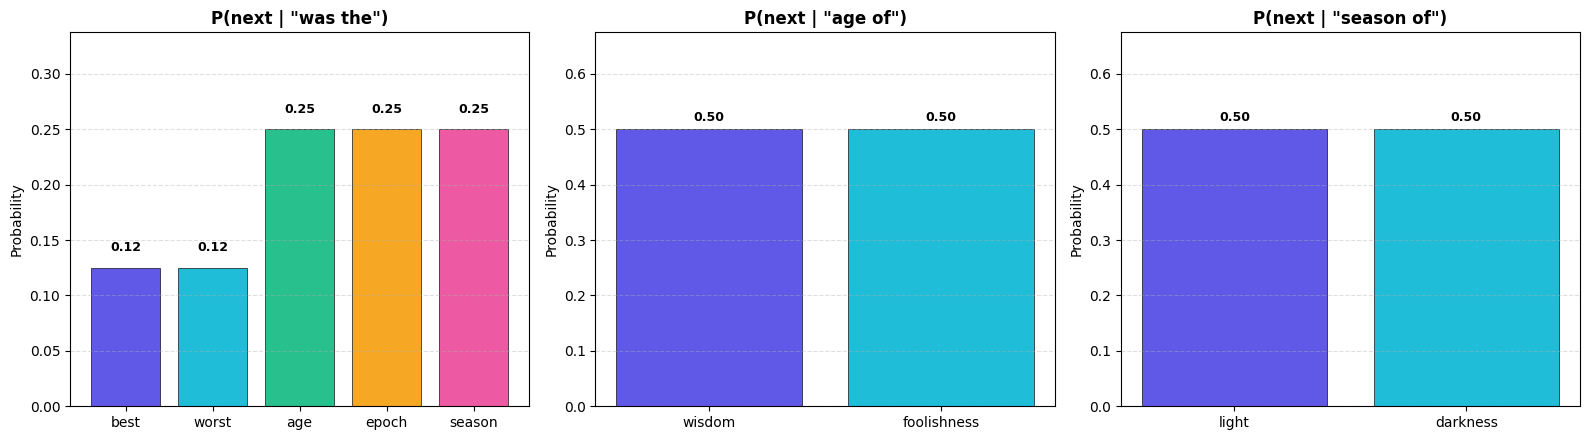

In [7]:
sample_prefixes = [
    ("was", "the"),
    ("age", "of"),
    ("season", "of")
]

palette = ["#4F46E5", "#06B6D4", "#10B981", "#F59E0B", "#EC4899", "#8B5CF6"]
fig, axes = plt.subplots(1, len(sample_prefixes), figsize=(16, 4.5))

for ax, prefix in zip(axes, sample_prefixes):
    probs = word_markov.get_probabilities(prefix)
    tokens = list(probs.keys())
    probabilities = list(probs.values())
    prefix_str = ' '.join(prefix)
    bar_colors = [palette[i % len(palette)] for i in range(len(tokens))]

    bars = ax.bar(tokens, probabilities, color=bar_colors, alpha=0.9, edgecolor="black", linewidth=0.5)
    ax.set_title(f'P(next | "{prefix_str}")', fontsize=12, fontweight='bold')
    ax.set_ylabel("Probability", fontsize=10)
    ax.set_ylim(0, max(probabilities) * 1.35 if probabilities else 1.0)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    for bar, p in zip(bars, probabilities):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015, f"{p:.2f}", ha="center", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
temperatures = [0.3, 0.7, 1.0, 1.5]
print("=" * 80)
print("TEXT GENERATION UNDER DIFFERENT TEMPERATURES (Word-Level, k=2)")
print("=" * 80)

for temp in temperatures:
    sample = word_markov.generate(max_words=30, temperature=temp, prompt="It was", seed=42)
    print(f"\n[Temperature = {temp:.1f}]")
    print(f"-> {sample}")
print("\n" + "=" * 80)

TEXT GENERATION UNDER DIFFERENT TEMPERATURES (Word-Level, k=2)

[Temperature = 0.3]
-> It was the age of wisdom, it was the epoch of belief, it was the epoch of incredulity, it was the epoch of incredulity, it was

[Temperature = 0.7]
-> It was the age of wisdom, it was the epoch of belief, it was the season of darkness. We had everything before us, we were all

[Temperature = 1.0]
-> It was the age of wisdom, it was the epoch of belief, it was the season of darkness. We had everything before us, we were all

[Temperature = 1.5]
-> It was the age of wisdom, it was the epoch of belief, it was the season of darkness. We had everything before us, we were all



In [9]:
prompts = ["Machine learning", "To be", "Artificial intelligence"]

print("=" * 80)
print("WORD-LEVEL vs CHARACTER-LEVEL GENERATION BENCHMARK")
print("=" * 80)

for p in prompts:
    word_out = word_markov.generate(max_words=25, prompt=p, temperature=0.8, seed=123)
    char_out = char_markov.generate(max_chars=140, prompt=p, temperature=0.8, seed=123)
    print(f"\nInput Prompt: '{p}'")
    print(f"  [Word Markov] : {word_out}")
    print(f"  [Char Markov] : {char_out}")

WORD-LEVEL vs CHARACTER-LEVEL GENERATION BENCHMARK

Input Prompt: 'Machine learning'
  [Word Markov] : Machine learning pipelines involve data collection, preprocessing, exploratory analysis, model training, hyperparameter tuning, and deployment. Large language models build
  [Char Markov] : Machine learning algorithms have revolution mechanisms, we had everything direct the epoch of incredulity of context world's a sequence and 

Input Prompt: 'To be'
  [Word Markov] : To be or not to be, that is the question: whether tis nobler in the previous event. In statistical modeling, n
  [Char Markov] : To be or to be or not to take arms against a sea of the other way.
    deployment. In state attained in the epoch of darkness.
    To be, th

Input Prompt: 'Artificial intelligence'
  [Word Markov] : Artificial intelligence and machine learning algorithms have revolutionized natural language processing. A Markov chain is a stochastic model describing a sequence of possible events
  [Char Marko

Order k=1 | Perplexity (PPL): 43.24
Order k=2 | Perplexity (PPL): 60.21
Order k=3 | Perplexity (PPL): 95.60
Order k=4 | Perplexity (PPL): 121.60


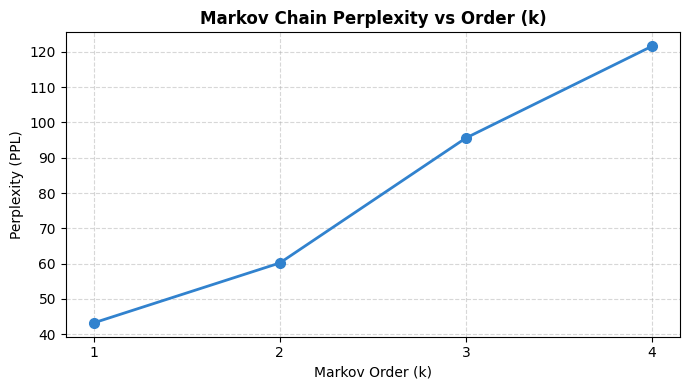

In [10]:
test_eval_text = "A Markov chain describes a sequence of possible events where the probability depends on previous states."
orders = [1, 2, 3, 4]
ppl_scores = []

for k in orders:
    model_k = WordMarkovChain(order=k)
    model_k.train(combined_corpus)
    ppl = MarkovModelEvaluator.calculate_perplexity(model_k, test_eval_text)
    ppl_scores.append(ppl)
    print(f"Order k={k} | Perplexity (PPL): {ppl:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(orders, ppl_scores, marker='o', color='#3182CE', linewidth=2, markersize=7)
plt.title("Markov Chain Perplexity vs Order (k)", fontsize=12, fontweight='bold')
plt.xlabel("Markov Order (k)", fontsize=10)
plt.ylabel("Perplexity (PPL)", fontsize=10)
plt.xticks(orders)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
export_path = "markov_model_trained.json"
word_markov.save_model(export_path)
print(f"Model successfully exported to {export_path}")

loaded_model = WordMarkovChain(order=2)
loaded_model.load_model(export_path)
print("Loaded model generation test:")
print("->", loaded_model.generate(max_words=25, seed=99))

Model successfully exported to markov_model_trained.json
Loaded model generation test:
-> Large language models build upon high dimensional embeddings and self attention mechanisms, while discrete Markov models provide transparent, interpretable, and deployment.
